In [ ]:
using LinearAlgebra
using BSplineKit
using PyCall
using DelimitedFiles
using Plots
using NonlinearEigenproblems
include("BaseFlow_cavity.jl")
include("Stability_Cavity.jl")

In [82]:
Res = 1000
N_cheb = 129
mode = 1
Ro = - 1.0
Co = 2 - Ro - Ro^2
Ts = 0
u0,v0,w0,du0,dv0,x = CRC_BF.BaseFlow(Res,Ro,Ts,mode)
D,D2,z = CRC_BF.Cheb(N_cheb,mode)
F,G,H = CRC_BF.interp(u0,v0,w0,z,N_cheb,mode)

([5.571387790627965e-22; 0.002206589144262123; … ; -0.0007719927481758681; -3.6829751484828996e-19;;], [1.0; 0.9975417112810868; … ; 0.000634301533347684; -1.589168536091337e-19;;], [-2.2957476588522552e-21; -1.0359793515841975e-5; … ; -3.6212129157292108e-6; -1.0773200297890632e-20;;])

In [83]:
R = 500
be = 0.1
OMEGA = 0.0
omega = OMEGA/R
c = 0.4
cof = CRC_STA.Spatial_mode_BEK1((F),(G.-1),(H),R,N_cheb,D,D2,Res)
L0_raw,L1_raw,L2_raw= CRC_STA.assemble_mat(cof,D,D2,be,omega,R)     
L0,L1,L2 = CRC_STA.boudary_condition(L0_raw,L1_raw,L2_raw,N_cheb,mode)
nep = PEP([L0,L1,L2]);
eigval,eigvec = iar(nep, σ = c, neigs = 3,maxit = 500 , tol=1e-14)
vel = CRC_STA.eig_full(eigvec,N_cheb,1)
@show eigval

eigval = ComplexF64[0.4266506820308528 - 0.06669228144735907im, 0.23552800140748598 + 0.058519441769064935im, 0.33678659645457015 + 0.21005769604977467im]


3-element Vector{ComplexF64}:
  0.4266506820308528 - 0.06669228144735907im
 0.23552800140748598 + 0.058519441769064935im
 0.33678659645457015 + 0.21005769604977467im

In [119]:
R = 500 
be = 0.0
alpha = 0.155
H0,H1 = CRC_STA.assemble_time_mat(cof,D,D2,be,alpha,R,N_cheb)
C = eigen(H0,H1)
val = C.values
vec = C.vectors
val = filter(x-> abs(real(x)) < 0.3 && abs(imag(x)) < 0.1, val)
# findmin(norm.(val))
val_target = val[findmax(imag.(val))[2]]
vec_target = vec[:,findmax(imag.(val))[2]];
val_target

-0.012213557481816555 + 0.004995896798545472im

In [121]:
H0,H1 = CRC_STA.assemble_time_mat(cof,D,D2,be+0.01,alpha,R,N_cheb)

(ComplexF64[97.5841698819475 + 0.0003174384301714973im -35.390373216877265 + 0.0im … 0.0 + 0.0im 0.0 + 0.0im; -16.436094612318993 + 0.0im 20.14286417793999 + 0.0012513064665097024im … 0.0 + 0.0im 0.0 + 0.0im; … ; 0.0 + 0.0im 0.0 + 0.0im … 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im … 0.0 + 0.0im 0.0 + 0.0im], ComplexF64[0.0 + 1.0im 0.0 + 0.0im … 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 1.0im … 0.0 + 0.0im 0.0 + 0.0im; … ; 0.0 + 0.0im 0.0 + 0.0im … 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im … 0.0 + 0.0im 0.0 + 0.0im])

In [122]:
val0,vec0 = rayleigh_quotient_iteration(H0,H1,val_target, vec_target )
val0

-0.00615854484485323 - 0.003216014946591271im

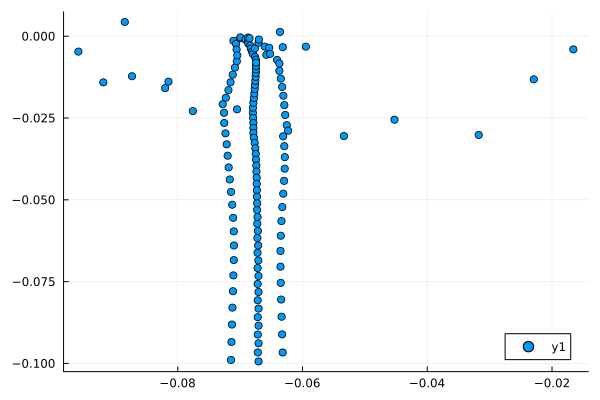

In [103]:
Plots.scatter(real(val),imag(val))

In [ ]:
function interation(R_ini, R_end, alpha_ini, alpha_end, be_ini, be_end, N_cheb)
    u0,v0,w0,du0,dv0,x = CRC_BF.BaseFlow(1000,-1,0.0,1)
    D,D2,z = CRC_BF.Cheb(N_cheb,1)
    F,G,H = CRC_BF.interp(u0,v0,w0,z,N_cheb,1)
    cof = CRC_STA.Spatial_mode_BEK1((F),(G.-1),(H),R_ini,N_cheb,D,D2,Res)
    H0,H1 = CRC_STA.assemble_time_mat(cof,D,D2,be_ini,alpha_ini,R_ini,N_cheb)
    C = eigen(H0,H1)
    val_all = C.values
    vec_all = C.vectors
    val_all = filter(x-> abs(real(x)) < 0.3 && abs(imag(x)) < 0.1, val_all)
    target_index = findmax(imag.(val_all))
    # target_index = findmin(norm.(val_all))
    val = val_all[target_index[2]]
    vec = vec_all[: , target_index[2]]
    data_all = [R_ini alpha_ini be_ini real(val) imag(val)]
    for R = R_ini : 5 : R_end
        cof = CRC_STA.Spatial_mode_BEK1((F),(G.-1),(H),R,N_cheb,D,D2, 1000)
        for alpha = alpha_ini  : 0.05 : alpha_end
            for be = be_ini+0.01 : 0.01 : be_end
                H0,H1 = CRC_STA.assemble_time_mat(cof,D,D2,be,alpha,R,N_cheb)
                val,vec = rayleigh_quotient_iteration(H0,H1,val, vec )
                data_all = [data_all; [R alpha be real(val) imag(val)]]
                writedlm("test.dat",data_all)
            end
        end
    end
end

interation (generic function with 4 methods)

In [127]:
using DelimitedFiles
using LinearAlgebra

function interation(R_ini, R_end, alpha_ini, alpha_end, be_ini, be_end, N_cheb, Res)
    # 1. 基础流与切比雪夫算子准备
    u0, v0, w0, du0, dv0, x = CRC_BF.BaseFlow(1000, -1, 0.0, 1)
    D, D2, z = CRC_BF.Cheb(N_cheb, 1)
    F, G, H = CRC_BF.interp(u0, v0, w0, z, N_cheb, 1)
    
    # 2. 全局谱获取初始模态 (修复 Res 未定义的问题，需作为参数传入)
    cof = CRC_STA.Spatial_mode_BEK1((F), (G.-1), (H), R_ini, N_cheb, D, D2, Res)
    H0, H1 = CRC_STA.assemble_time_mat(cof, D, D2, be_ini, alpha_ini, R_ini, N_cheb)
    C = eigen(H0, H1)
    val_all = C.values
    vec_all = C.vectors
    
    # 3. 修复索引错位问题：获取符合条件的原始索引
    valid_indices = findall(x -> abs(real(x)) < 0.3 && abs(imag(x)) < 0.1, val_all)
    if isempty(valid_indices)
        error("未找到满足过滤条件的初始模态！")
    end
    # 在过滤后的结果中找最大虚部，并映射回原数组索引
    target_idx_in_valid = argmax(imag.(val_all[valid_indices]))
    actual_index = valid_indices[target_idx_in_valid]
    
    val_current = val_all[actual_index]
    vec_current = vec_all[:, actual_index]
    
    # 4. 初始化文件（清空或创建文件），写入表头(可选)
    filename = "test.dat"
    open(filename, "w") do io
        # 修复 R 未定义，使用 R_ini
        writedlm(io, [R_ini alpha_ini be_ini real(val_current) imag(val_current)])
    end

    # 5. 参数遍历追踪
    for R = R_ini : 5 : R_end
        cof = CRC_STA.Spatial_mode_BEK1((F), (G.-1), (H), R, N_cheb, D, D2, Res)
        
        for alpha = alpha_ini : 0.05 : alpha_end
            
            # 策略建议：为了防止 be 参数突变导致 RQI 追踪失败，
            # 每次 alpha 循环开始前，最好重新做一次全局特征值分析，或者保存前一个 alpha 在 be_ini 处的模态。
            # 这里暂时保留你的追踪逻辑，但你需要注意物理上的合理性。
            H0, H1 = CRC_STA.assemble_time_mat(cof, D, D2, be, alpha, R, N_cheb)
            C = eigen(H0, H1)
            val_all = C.values
            vec_all = C.vectors
            
            # 3. 修复索引错位问题：获取符合条件的原始索引
            valid_indices = findall(x -> abs(real(x)) < 0.3 && abs(imag(x)) < 0.1, val_all)
            if isempty(valid_indices)
                error("未找到满足过滤条件的初始模态！")
            end
            # 在过滤后的结果中找最大虚部，并映射回原数组索引
            target_idx_in_valid = argmax(imag.(val_all[valid_indices]))
            actual_index = valid_indices[target_idx_in_valid]
            
            val_current = val_all[actual_index]
            vec_current = vec_all[:, actual_index]
            val_track = val_current
            vec_track = vec_current
            for be = be_ini+0.01 : 0.01 : be_end
                H0, H1 = CRC_STA.assemble_time_mat(cof, D, D2, be, alpha, R, N_cheb)
                
                # RQI 追踪
                val_track, vec_track = rayleigh_quotient_iteration(H0, H1, val_track, vec_track)
                
                # 6. 性能优化：使用追加模式逐行写入，避免数组反复拼接
                open(filename, "a") do io
                    writedlm(io, [R alpha be real(val_track) imag(val_track)])
                end
            end
            
        end
    end
end

interation (generic function with 5 methods)

In [128]:
R_ini= 500
R_end = 500
be_ini = 0.0
be_end = 0.3
alpha_ini = 0.005
alpha_end = 1.0
N_cheb = 129
interation(R_ini, R_end, alpha_ini, alpha_end, be_ini, be_end, N_cheb, Res)

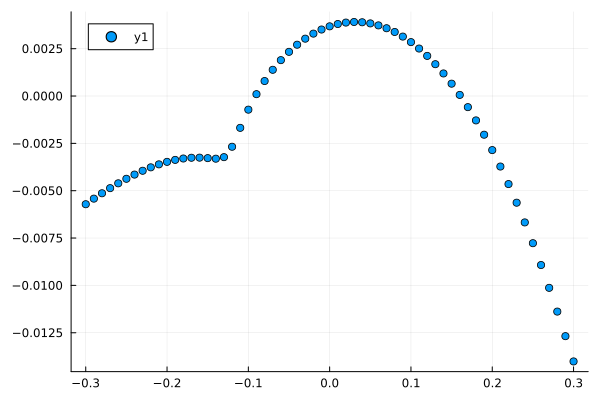

In [68]:
data = readdlm("test.dat")
Plots.scatter(data[:,3],data[:,5])

In [ ]:
function rayleigh_quotient_iteration(A, B, sigma, q0=rand(size(A, 1), 1))

    flg = true
    i=1
    while flg
        i=i+1
        sigma0 = real(sigma[1]) + abs(imag(sigma[1]))im + 0.0e0im
        q = (A - sigma*B) \ (B*q0)
        q0 = q/maximum(abs.(q))
        sigma = ((q0'*(A*q0))/(q0'*(B*q0)))[1]
        if abs(sigma-sigma0)<=eps(1.0f0)
            flg = false
        end
        if i==20
            flg=false
        end
    end

      return sigma, q0
end